In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import(train_test_split,cross_val_score)

from scipy.stats import kurtosis, skew

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import(accuracy_score,classification_report)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("combined_bearing_dataset.csv")
print(data.head())
print(data.shape)

     signal  label
0  0.167101  OR@12
1  0.159591  OR@12
2  0.128507  OR@12
3  0.076562  OR@12
4  0.023782  OR@12
(2432859, 2)


In [3]:
window_size=1000
features=[]
labels=[]

for fault in data["label"].unique():
    signal=data[data["label"]==fault]["signal"].values
    for i in range(0,len(signal)-window_size,100):
        window=signal[i:i+window_size]
        mean=np.mean(window)
        std=np.std(window)
        rms=np.sqrt(np.mean(window**2))
        maxi=np.max(window)
        mini=np.min(window)
        kurt=kurtosis(window)
        sk=skew(window)
        features.append([mean,std,rms,maxi,mini,kurt,sk])
        labels.append(fault)

In [4]:
feature_names=["mean","std","rms","max","min","kurtosis","skewness"]

X=pd.DataFrame(
    features,
    columns=feature_names
)

y=np.array(labels)

print("Shape of X :",X.shape)
print("Shape of y :",y.shape)

Shape of X : (24281, 7)
Shape of y : (24281,)


In [5]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
import joblib
scaler=joblib.load("scaler.pkl")
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_scaled=scaler.transform(X)

In [7]:
models={
    "KNN":
    KNeighborsClassifier(n_neighbors=5),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=50,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "SVM": SVC(kernel="rbf", probability=True),

    "Naive Bayes":
    GaussianNB(),

    "Logistic Regression":
    LogisticRegression(max_iter=1000),
}

In [8]:
results=[]
for name, model in models.items():
    print("\n"+"="*25)
    print(name)
    print("="*25)
    model.fit(X_train_scaled,y_train)
    y_pred=model.predict(X_test_scaled)
    test_accuracy=accuracy_score(y_test,y_pred)
    cv_accuracy=cross_val_score(model,X_scaled,y,cv=5).mean()
    results.append([name,test_accuracy,cv_accuracy])
    print(f"Test Accuracy:{test_accuracy*100:.2f}%")
    print(f"CV Accuracy:{cv_accuracy*100:.2f}%")


KNN
Test Accuracy:98.15%
CV Accuracy:96.05%

Random Forest
Test Accuracy:96.85%
CV Accuracy:96.16%

Decision Tree
Test Accuracy:97.71%
CV Accuracy:95.73%

SVM
Test Accuracy:95.47%
CV Accuracy:95.24%

Naive Bayes
Test Accuracy:96.05%
CV Accuracy:95.84%

Logistic Regression
Test Accuracy:95.16%
CV Accuracy:94.53%


In [9]:
results_df=pd.DataFrame(
    results,
    columns=["Classifier","Test Accuracy","CV Accuracy"]
)
results_df=results_df.sort_values(
    by="Test Accuracy",
    ascending=False
)
results_df

,Classifier,Test Accuracy,CV Accuracy
0,KNN,0.981470,0.960546
2,Decision Tree,0.977146,0.957292
1,Random Forest,0.968499,0.961575
4,Naive Bayes,0.960469,0.958404
3,SVM,0.954705,0.952432
5,Logistic Regression,0.951616,0.945348


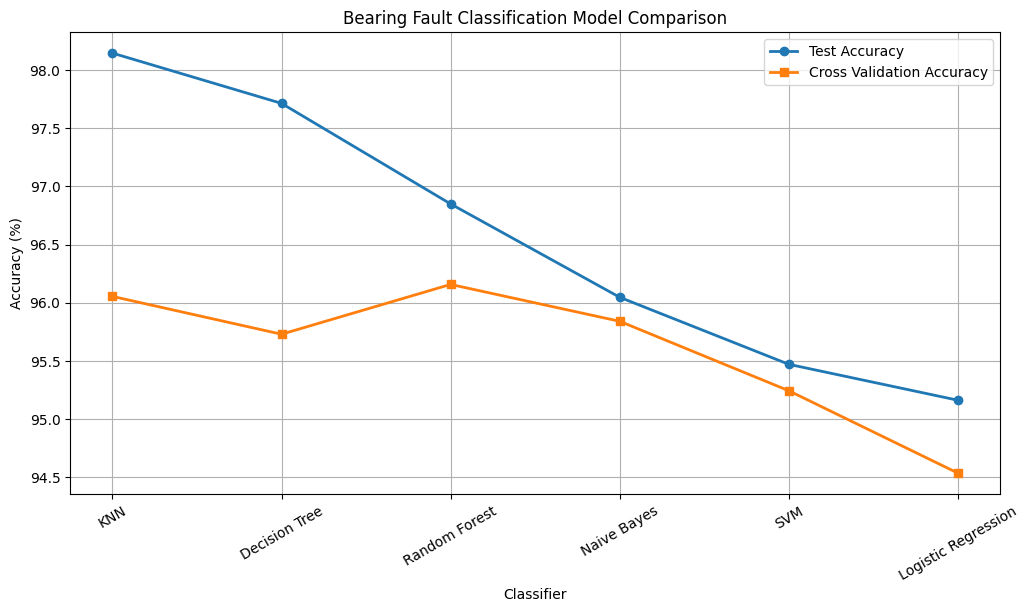

In [10]:
plt.figure(figsize=(12,6))
plt.plot(
    results_df["Classifier"],
    results_df["Test Accuracy"]*100,
    marker="o",
    linewidth=2,
    label="Test Accuracy"
)

plt.plot(
    results_df["Classifier"],
    results_df["CV Accuracy"]*100,
    marker="s",
    linewidth=2,
    label="Cross Validation Accuracy"
)

plt.xticks(rotation=30)
plt.ylabel("Accuracy (%)")
plt.xlabel("Classifier")
plt.title("Bearing Fault Classification Model Comparison")
plt.grid(True)
plt.legend()
plt.show()

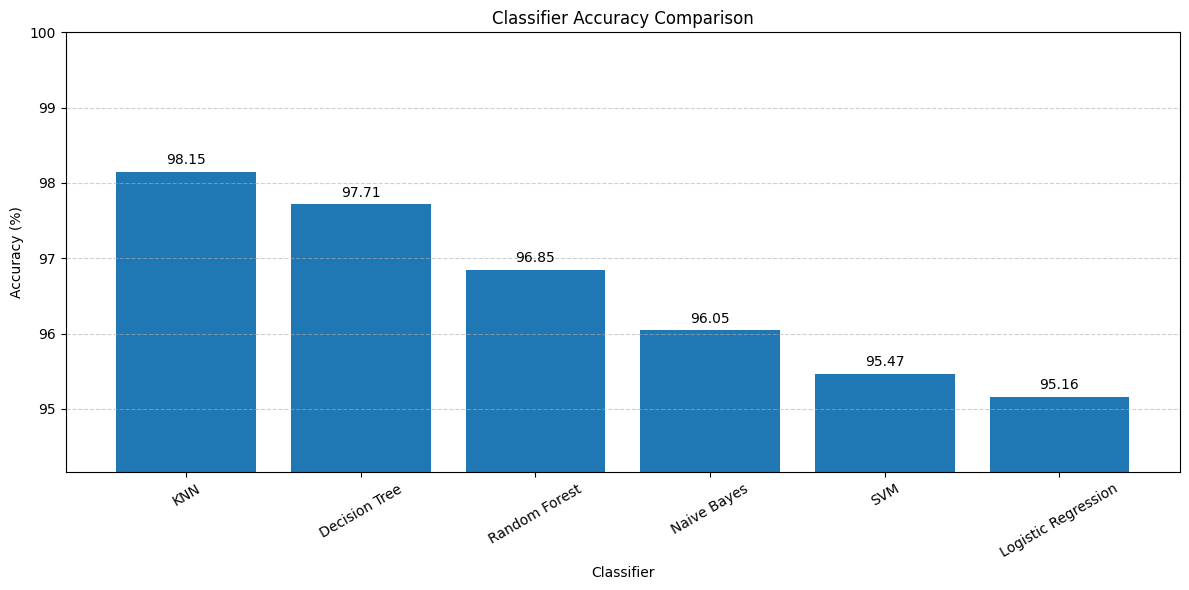

In [11]:
plt.figure(figsize=(12,6))
bars=plt.bar(results_df["Classifier"],results_df["Test Accuracy"]*100)

# Show accuracy values on top of bars
for bar in bars:
    height=bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f"{height:.2f}",
        ha='center'
    )

plt.xticks(rotation=30)

plt.ylabel("Accuracy (%)")
plt.xlabel("Classifier")

plt.title("Classifier Accuracy Comparison")

# Zoom into the important range
plt.ylim(results_df["Test Accuracy"].min()*100-1,100)
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

In [12]:
print(models["SVM"])

SVC(probability=True)


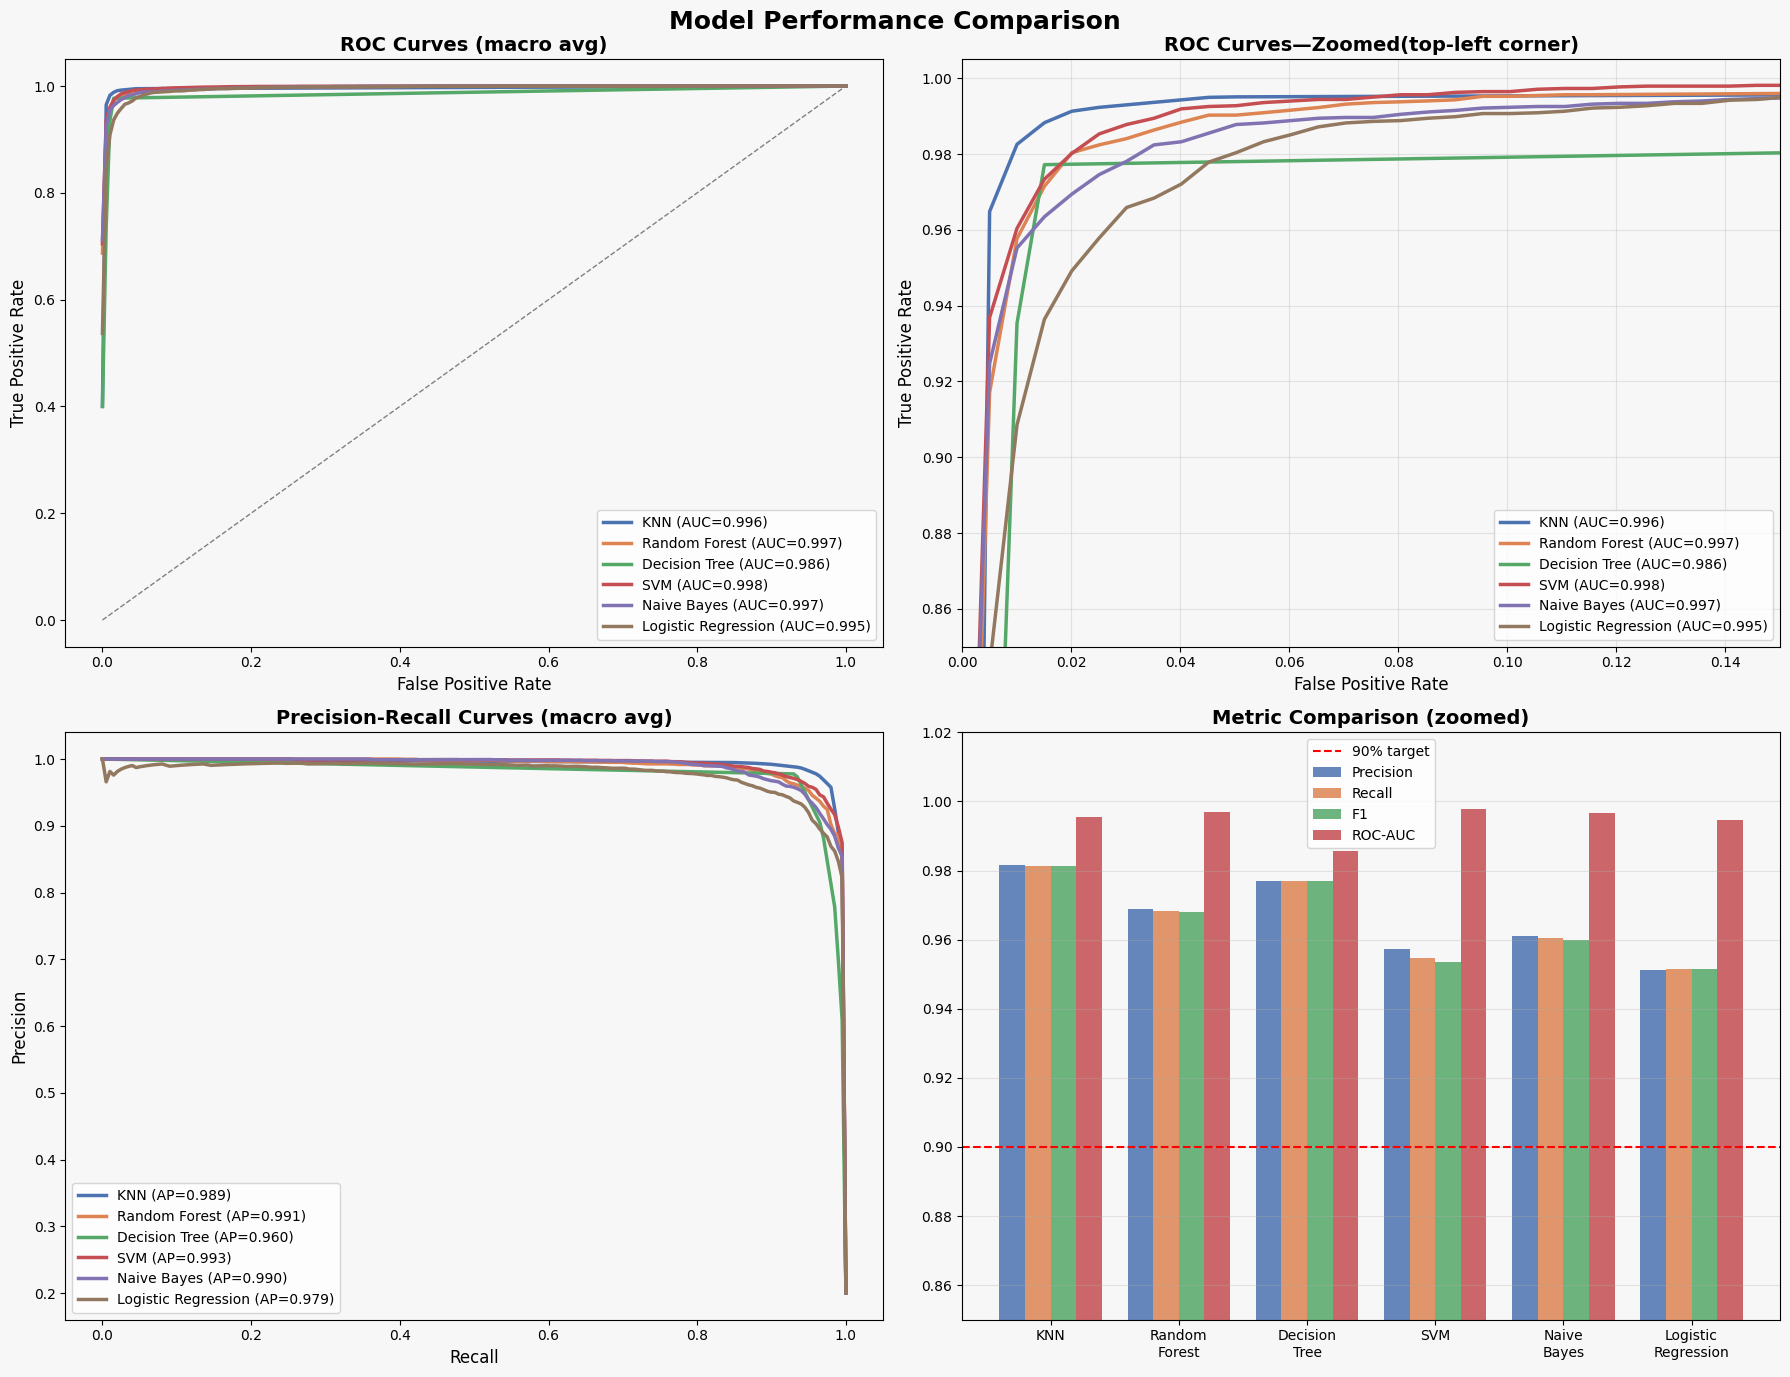

In [28]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import(
    roc_curve,auc,precision_recall_curve,average_precision_score,
    precision_score,recall_score,f1_score
)
BG='#f7f7f7'
PALETTE=['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
classes=sorted(np.unique(y))
n_classes=len(classes)
y_test_bin=label_binarize(y_test,classes=classes)
fpr_grid=np.linspace(0,1,200)
recall_grid=np.linspace(0,1,200)
results={}
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pred=model.predict(X_test_scaled)
    if not hasattr(model, "predict_proba"):
        print(f"Skipping {name} (no predict_proba)")
        continue
    y_score=model.predict_proba(X_test_scaled)
    tpr_interp=[]
    for i in range(n_classes):
        fpr_i,tpr_i,_=roc_curve(y_test_bin[:,i],y_score[:,i])
        tpr_interp.append(np.interp(fpr_grid,fpr_i,tpr_i))
    mean_tpr=np.mean(tpr_interp,axis=0)
    roc_auc_val=auc(fpr_grid,mean_tpr)
    prec_interp=[]
    ap_scores=[]
    for i in range(n_classes):
        prec_i,rec_i,_=precision_recall_curve(y_test_bin[:,i],y_score[:,i])
        prec_interp.append(np.interp(recall_grid,rec_i[::-1],prec_i[::-1]))
        ap_scores.append(average_precision_score(y_test_bin[:, i],y_score[:, i]))
    mean_prec=np.mean(prec_interp,axis=0)
    avg_prec=np.mean(ap_scores)
    results[name]={
        'fpr':fpr_grid,
        'tpr':mean_tpr, 
        'roc_auc':roc_auc_val,
        'recalls':recall_grid, 
        'precisions':mean_prec, 
        'avg_prec':avg_prec,
        'precision':precision_score(y_test,y_pred,average='macro'),
        'recall': recall_score(y_test, y_pred, average='macro'),
        'f1': f1_score(y_test, y_pred, average='macro'),
    }

# BIGGER figure,2x2 layout:full ROC,zoomed ROC,full PR,metrics
fig,axes=plt.subplots(2,2,figsize=(18, 14),facecolor=BG)
fig.suptitle('Model Performance Comparison',fontsize=18,fontweight='bold')
for ax in axes.flat:
    ax.set_facecolor(BG)
# Full ROC 
ax=axes[0, 0]
for(name,r),c in zip(results.items(),PALETTE):
    ax.plot(r['fpr'],r['tpr'],color=c,lw=2.5,label=f'{name} (AUC={r["roc_auc"]:.3f})')
ax.plot([0, 1],[0, 1],'--',color='gray',lw=1)
ax.set_xlabel('False Positive Rate',fontsize=12)
ax.set_ylabel('True Positive Rate',fontsize=12)
ax.set_title('ROC Curves (macro avg)',fontweight='bold',fontsize=14)
ax.legend(fontsize=10,loc='lower right')
ax.tick_params(labelsize=10)
# Zoomed-in ROC(top-left corner where the real differences show)
ax=axes[0,1]
for(name,r),c in zip(results.items(),PALETTE):
    ax.plot(r['fpr'],r['tpr'],color=c,lw=2.5,label=f'{name} (AUC={r["roc_auc"]:.3f})')
ax.set_xlim(0,0.15)
ax.set_ylim(0.85,1.005)
ax.set_xlabel('False Positive Rate',fontsize=12)
ax.set_ylabel('True Positive Rate',fontsize=12)
ax.set_title('ROC Curves—Zoomed(top-left corner)',fontweight='bold',fontsize=14)
ax.legend(fontsize=10,loc='lower right')
ax.tick_params(labelsize=10)
ax.grid(True,alpha=0.3)
# PR curves 
ax=axes[1,0]
for(name,r),c in zip(results.items(),PALETTE):
    ax.plot(r['recalls'],r['precisions'],color=c,lw=2.5,label=f'{name} (AP={r["avg_prec"]:.3f})')
ax.set_xlabel('Recall',fontsize=12)
ax.set_ylabel('Precision',fontsize=12)
ax.set_title('Precision-Recall Curves (macro avg)',fontweight='bold',fontsize=14)
ax.legend(fontsize=10,loc='lower left')
ax.tick_params(labelsize=10)
# Metric bars 
ax=axes[1,1]
mdf=pd.DataFrame({n: {'Precision': r['precision'], 'Recall': r['recall'],
                         'F1': r['f1'], 'ROC-AUC': r['roc_auc']}
                    for n, r in results.items()}).T
xs=np.arange(len(mdf))
for i,(m,c) in enumerate(zip(['Precision','Recall','F1','ROC-AUC'],PALETTE)):
    ax.bar(xs+i*0.2,mdf[m],0.2,label=m,color=c,alpha=0.85)
ax.set_xticks(xs+0.3)
ax.set_xticklabels([n.replace(' ','\n') for n in mdf.index],fontsize=11)
ax.set_ylim(0.85,1.02)  # zoomed y-axis to show differences clearly
ax.axhline(0.90,color='red',ls='--',lw=1.5,label='90% target')
ax.set_title('Metric Comparison (zoomed)',fontweight='bold',fontsize=14)
ax.legend(fontsize=10)
ax.tick_params(labelsize=10)
ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig('fig_models_large.png',dpi=150,bbox_inches='tight')
plt.show()

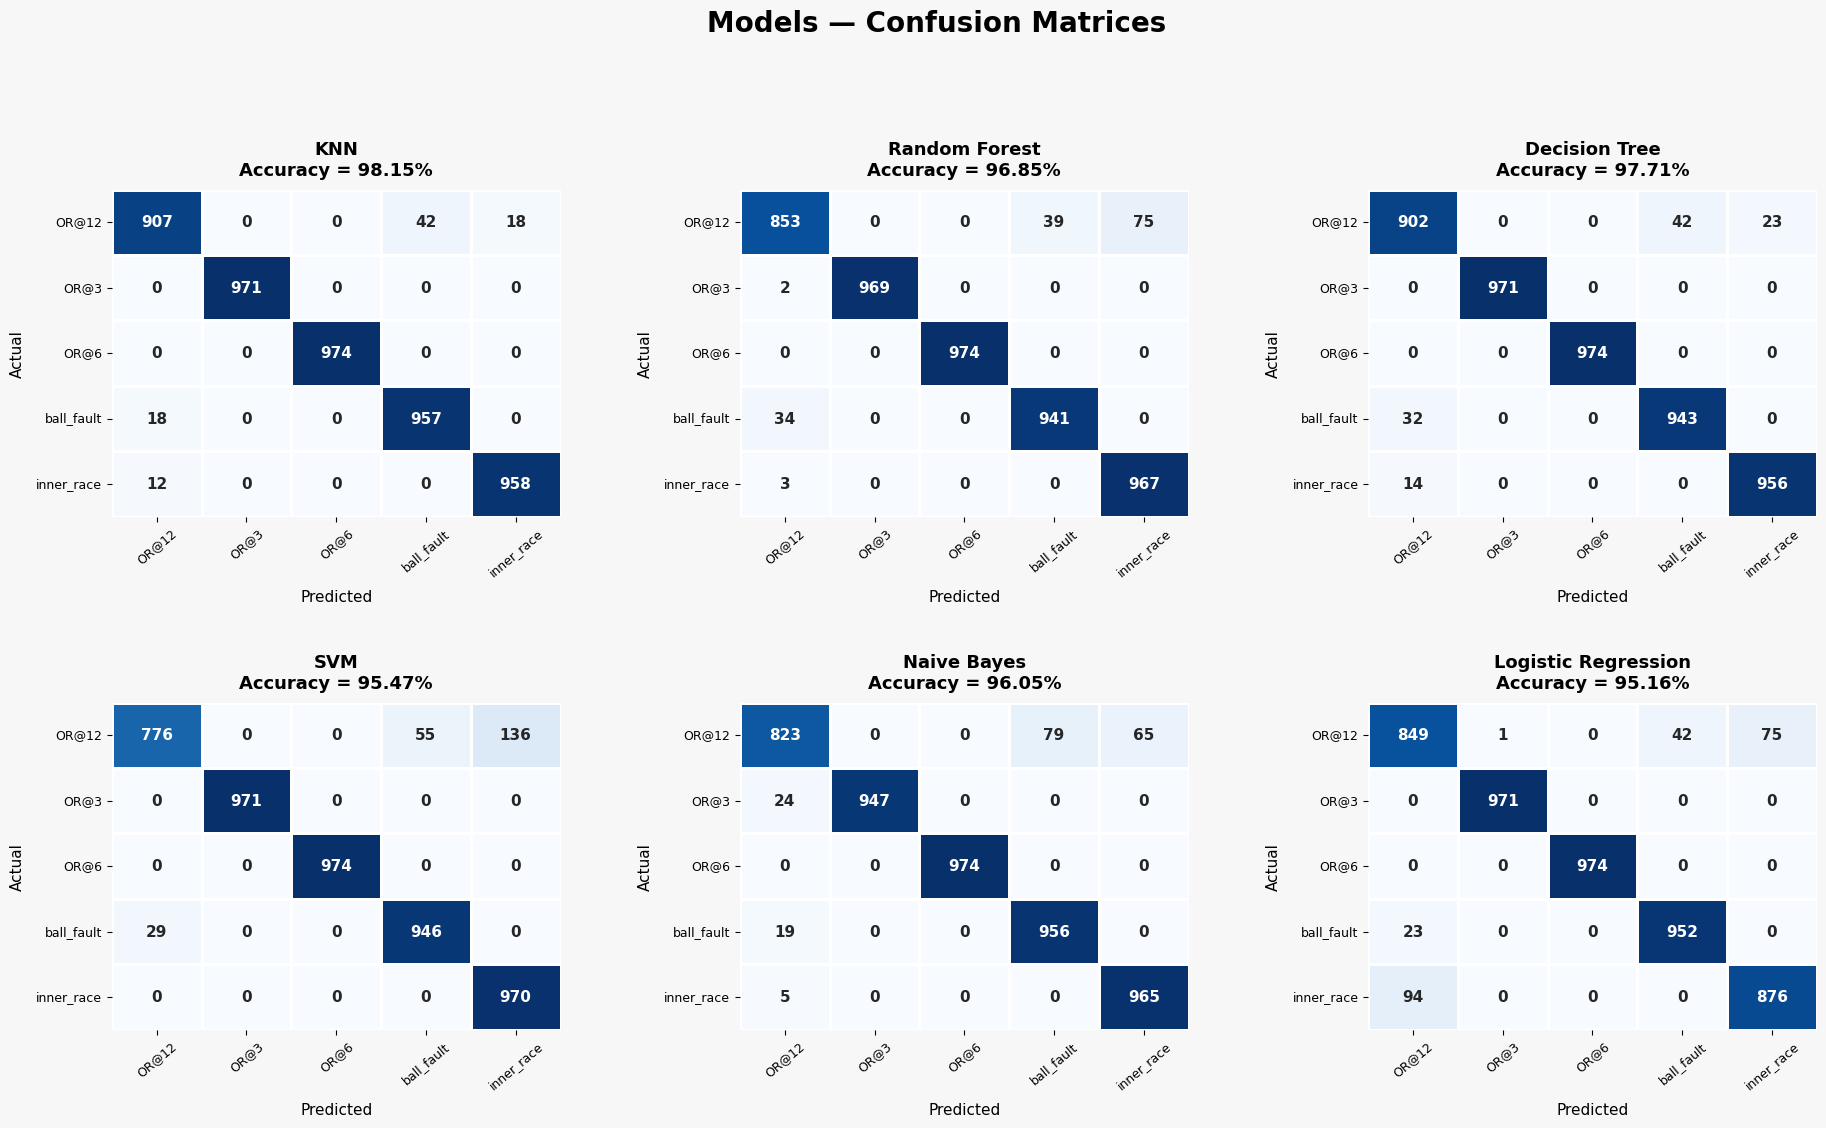

In [26]:
from sklearn.metrics import confusion_matrix, precision_recall_curve
from sklearn.preprocessing import label_binarize
from matplotlib.gridspec import GridSpec
import seaborn as sns

BG = '#f7f7f7'
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

classes = sorted(np.unique(y))
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)
threshold_grid = np.linspace(0.01, 0.99, 200)

model_results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    if not hasattr(model, "predict_proba"):
        print(f"Skipping {name} (no predict_proba)")
        continue

    y_score = model.predict_proba(X_test_scaled)

    prec_all, rec_all = [], []
    for i in range(n_classes):
        p_i, r_i, t_i = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        p_i, r_i, t_i = p_i[:-1], r_i[:-1], t_i
        prec_all.append(np.interp(threshold_grid, t_i, p_i))
        rec_all.append(np.interp(threshold_grid, t_i, r_i))

    pr = np.mean(prec_all, axis=0)
    re = np.mean(rec_all, axis=0)
    f1 = 2 * pr * re / (pr + re + 1e-9)
    best_idx = np.argmax(f1)

    model_results[name] = {
        'y_pred': y_pred, 'pr': pr, 're': re, 'f1': f1,
        'optimal_threshold': threshold_grid[best_idx]
    }

# ─── Figure setup with GridSpec for clean spacing ──────────────────
fig = plt.figure(figsize=(22, 18), facecolor=BG)
gs = GridSpec(3, 3, figure=fig, height_ratios=[1, 1, 1.1], hspace=0.55, wspace=0.4)

fig.suptitle('Models — Confusion Matrices',
             fontsize=20, fontweight='bold', y=0.98)

# ─── Top + middle rows: 6 confusion matrices, 2x3 grid ─────────────
for idx, (name, r) in enumerate(model_results.items()):
    row, col = divmod(idx, 3)
    ax = fig.add_subplot(gs[row, col])
    ax.set_facecolor(BG)
    cm = confusion_matrix(y_test, r['y_pred'], labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=classes, yticklabels=classes,
                linewidths=0.8, linecolor='white', cbar=False,
                annot_kws={'size': 11, 'weight': 'bold'})
    acc = np.trace(cm) / np.sum(cm)
    ax.set_title(f'{name}\nAccuracy = {acc*100:.2f}%', fontweight='bold', fontsize=13, pad=10)
    ax.set_xlabel('Predicted', fontsize=11, labelpad=8)
    ax.set_ylabel('Actual', fontsize=11, labelpad=8)
    ax.tick_params(axis='x', rotation=40, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.savefig('fig_evaluation_all_models.png', dpi=160, bbox_inches='tight', facecolor=BG)
plt.show()

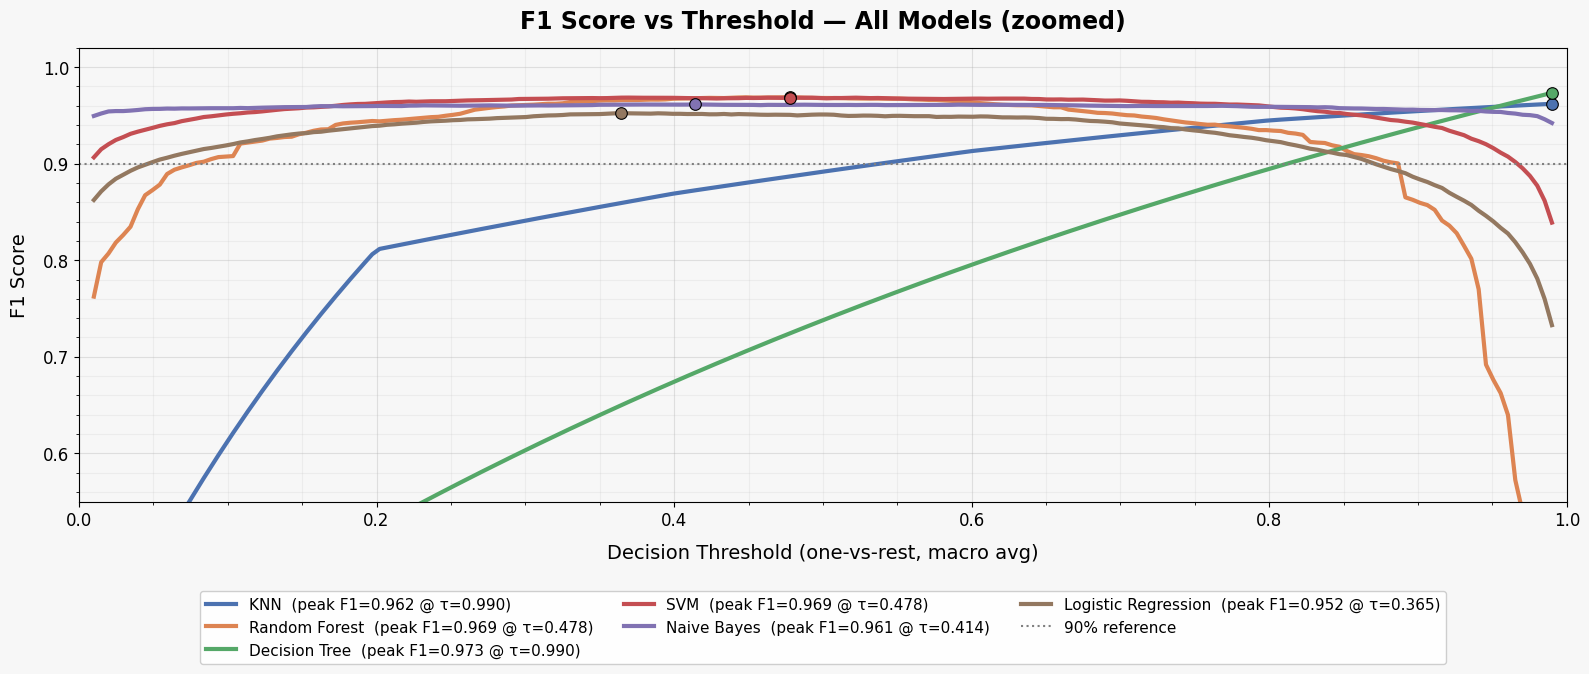

In [27]:
fig, ax = plt.subplots(figsize=(16, 7), facecolor=BG)
ax.set_facecolor(BG)

for (name, r), c in zip(model_results.items(), PALETTE):
    ax.plot(threshold_grid, r['f1'], color=c, lw=3,
            label=f"{name}  (peak F1={r['f1'].max():.3f} @ τ={r['optimal_threshold']:.3f})")
    peak_idx = np.argmax(r['f1'])
    ax.scatter(threshold_grid[peak_idx], r['f1'][peak_idx], color=c, s=70,
               zorder=5, edgecolor='black', linewidth=0.8)

ax.axhline(0.90, color='gray', ls=':', lw=1.5, label='90% reference')

# Zoom into the range where the real differences are visible
ax.set_ylim(0.55, 1.02)
ax.set_xlim(0, 1)

ax.set_xlabel('Decision Threshold (one-vs-rest, macro avg)', fontsize=14, labelpad=10)
ax.set_ylabel('F1 Score', fontsize=14, labelpad=10)
ax.set_title('F1 Score vs Threshold — All Models (zoomed)', fontweight='bold', fontsize=17, pad=14)

# Legend OUTSIDE the plot, below, so it never overlaps the curves
ax.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, -0.18),
          ncol=3, frameon=True, facecolor='white', framealpha=0.95)

ax.grid(True, which='major', alpha=0.35)
ax.minorticks_on()
ax.grid(True, which='minor', alpha=0.15)
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig('fig_threshold_zoomed.png', dpi=160, bbox_inches='tight', facecolor=BG)
plt.show()

In [31]:
results_df=results_df.sort_values(by="Test Accuracy",ascending=False).reset_index(drop=True)
best_classifier=results_df.iloc[0]["Classifier"]
 
best_model=models[best_classifier]
best_model.fit(X_train_scaled,y_train)
y_pred=best_model.predict(X_test_scaled)
 
print("\nBest Model:",best_classifier)
print(classification_report(y_test,y_pred))
 
best_test_accuracy=results_df.loc[results_df["Classifier"]==best_classifier,"Test Accuracy"].values[0]*100
best_cv_accuracy=results_df.loc[results_df["Classifier"]==best_classifier,"CV Accuracy"].values[0]*100


Best Model: KNN
              precision    recall  f1-score   support

       OR@12       0.97      0.94      0.95       967
        OR@3       1.00      1.00      1.00       971
        OR@6       1.00      1.00      1.00       974
  ball_fault       0.96      0.98      0.97       975
  inner_race       0.98      0.99      0.98       970

    accuracy                           0.98      4857
   macro avg       0.98      0.98      0.98      4857
weighted avg       0.98      0.98      0.98      4857



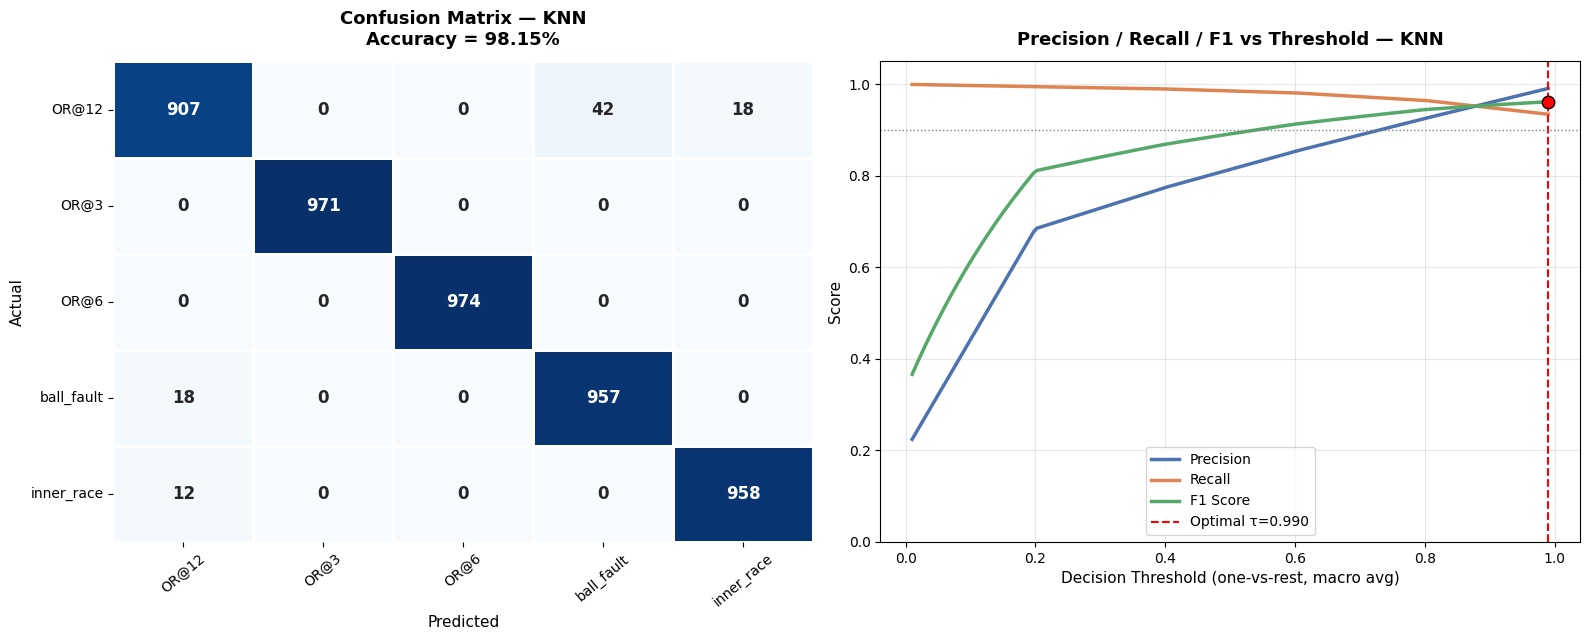

In [34]:
from sklearn.metrics import confusion_matrix, precision_recall_curve
from sklearn.preprocessing import label_binarize
import seaborn as sns
import numpy as np

# Best model: KNN 
best_classifier=results_df.iloc[0]["Classifier"]
best_model=models[best_classifier]
best_model.fit(X_train_scaled, y_train)
y_pred=best_model.predict(X_test_scaled)
y_score=best_model.predict_proba(X_test_scaled)
classes=sorted(np.unique(y))
n_classes=len(classes)
y_test_bin=label_binarize(y_test,classes=classes)
threshold_grid=np.linspace(0.01,0.99,200)
fig,axes=plt.subplots(1,2,figsize=(16,6.5),facecolor='white')
# Confusion matrix 
ax=axes[0]
cm=confusion_matrix(y_test,y_pred,labels=classes)
sns.heatmap(cm, annot=True,fmt='d',cmap='Blues',ax=ax,
            xticklabels=classes,yticklabels=classes,
            linewidths=0.8,linecolor='white',cbar=False,
            annot_kws={'size':12,'weight':'bold'})
acc=np.trace(cm)/np.sum(cm)
ax.set_title(f'Confusion Matrix — {best_classifier}\nAccuracy={acc*100:.2f}%',
             fontweight='bold',fontsize=13,pad=12)
ax.set_xlabel('Predicted',fontsize=11)
ax.set_ylabel('Actual',fontsize=11)
ax.tick_params(axis='x',rotation=40,labelsize=10)
ax.tick_params(axis='y',rotation=0,labelsize=10)
# Precision/Recall/F1 vs Threshold (macro avg, one-vs-rest)
ax=axes[1]
prec_all,rec_all=[],[]
for i in range(n_classes):
    p_i,r_i,t_i =precision_recall_curve(y_test_bin[:,i],y_score[:,i])
    p_i,r_i,t_i=p_i[:-1],r_i[:-1],t_i
    prec_all.append(np.interp(threshold_grid,t_i,p_i))
    rec_all.append(np.interp(threshold_grid,t_i,r_i))
pr=np.mean(prec_all,axis=0)
re=np.mean(rec_all, axis=0)
f1=2*pr*re/(pr+re+1e-9)
best_idx=np.argmax(f1)
optimal_threshold=threshold_grid[best_idx]
ax.plot(threshold_grid,pr,color='#4C72B0',lw=2.5,label='Precision')
ax.plot(threshold_grid,re,color='#DD8452',lw=2.5,label='Recall')
ax.plot(threshold_grid,f1,color='#55A868',lw=2.5,label='F1 Score')
ax.scatter(optimal_threshold,f1[best_idx],color='red',s=80,zorder=5,
           edgecolor='black',linewidth=1)
ax.axvline(optimal_threshold,color='red',ls='--',lw=1.5,
           label=f'Optimal τ={optimal_threshold:.3f}')
ax.axhline(0.90,color='gray',ls=':',lw=1)
ax.set_xlabel('Decision Threshold(one-vs-rest, macro avg)',fontsize=11)
ax.set_ylabel('Score',fontsize=11)
ax.set_title(f'Precision/Recall/F1 vs Threshold—{best_classifier}',
             fontweight='bold',fontsize=13,pad=12)
ax.legend(fontsize=10,loc='lower center')
ax.grid(True,alpha=0.3)
ax.set_ylim(0,1.05)
plt.tight_layout()
plt.savefig('fig_evaluation.png',dpi=200,bbox_inches='tight',facecolor='white')
plt.show()

In [36]:
print(
    f"""
The performance of multiple machine learning classifiers was evaluated using statistical features extracted from vibration signals.
 
Among all tested models, {best_classifier} was automatically selected as the best-performing classifier based on the criterion
M*=argmax_i(A[i]), where A[i] is the testing accuracy of model i. It achieved the highest test accuracy of
{best_test_accuracy:.2f}% among all models, along with a cross-validation accuracy of {best_cv_accuracy:.2f}%, confirming
that its performance is both high and consistent rather than a result of overfitting to one particular train/test split.
 
This comparison demonstrates that machine learning models can effectively distinguish between different bearing fault conditions,
making them suitable for predictive maintenance applications.
"""
)


The performance of multiple machine learning classifiers was evaluated using statistical features extracted from vibration signals.

Among all tested models, KNN was automatically selected as the best-performing classifier based on the criterion
M*=argmax_i(A[i]), where A[i] is the testing accuracy of model i. It achieved the highest test accuracy of
98.15% among all models, along with a cross-validation accuracy of 96.05%, confirming
that its performance is both high and consistent rather than a result of overfitting to one particular train/test split.

This comparison demonstrates that machine learning models can effectively distinguish between different bearing fault conditions,
making them suitable for predictive maintenance applications.

